Dataset loaded successfully!

First 5 rows:
  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
3                                                NaN            NaN   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

           date_added  release_year rating   duration  \
0  September 25, 2021          2020  PG-13     90 min   
1  September 24, 2021          2021  TV-MA

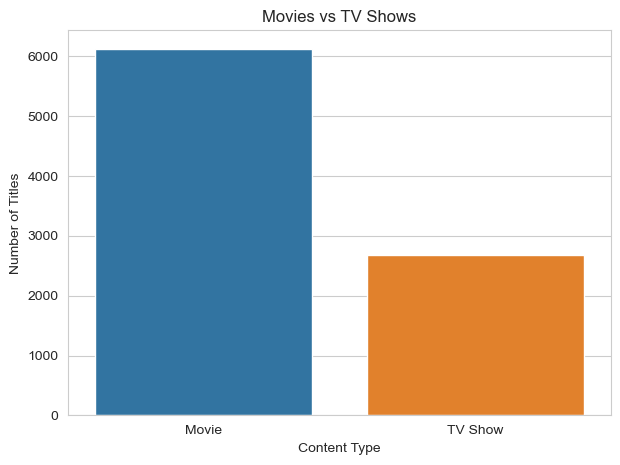


Rating Distribution:
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
Unknown        4
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: rating, dtype: int64


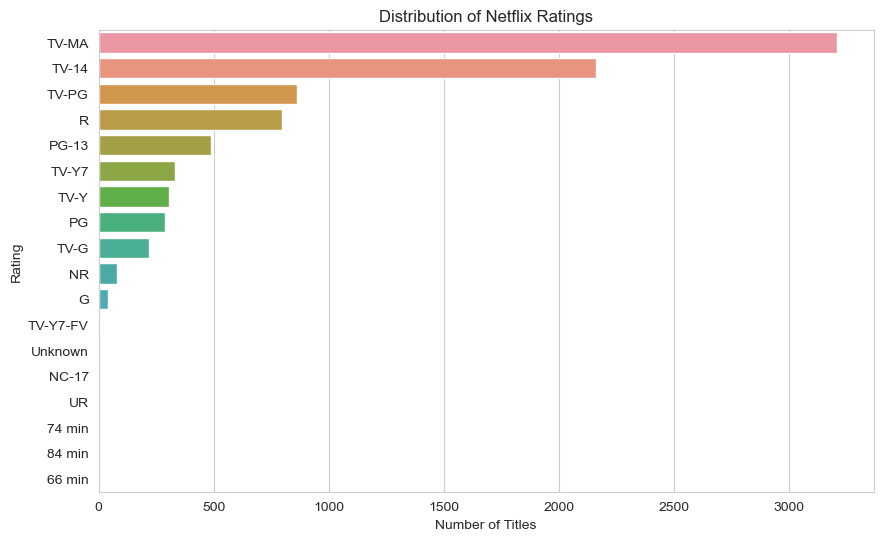


Top 10 Countries:
United States     3689
India             1046
Unknown            831
United Kingdom     804
Canada             445
France             393
Japan              318
Spain              232
South Korea        231
Germany            226
Name: country, dtype: int64


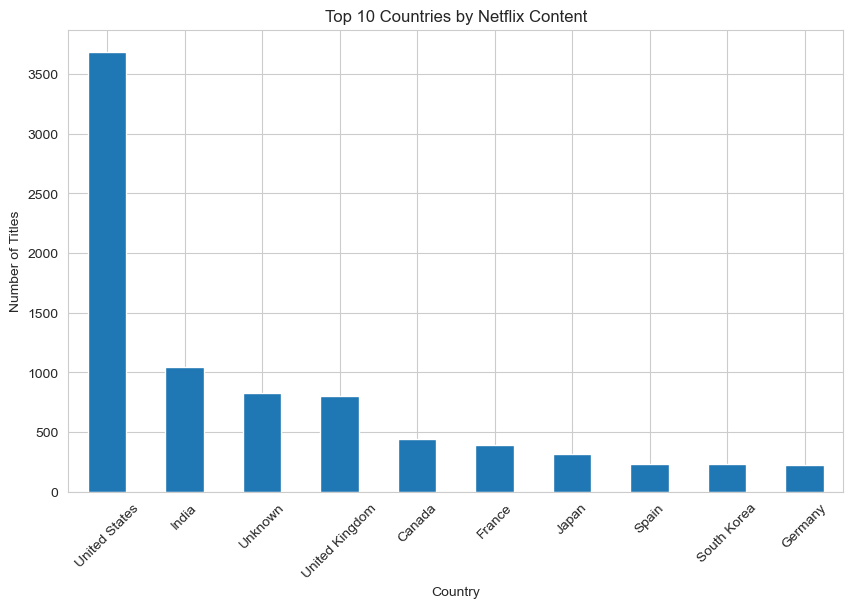


Top 10 Release Years:
2018    1147
2017    1032
2019    1030
2020     953
2016     902
2021     592
2015     560
2014     352
2013     288
2012     237
Name: release_year, dtype: int64


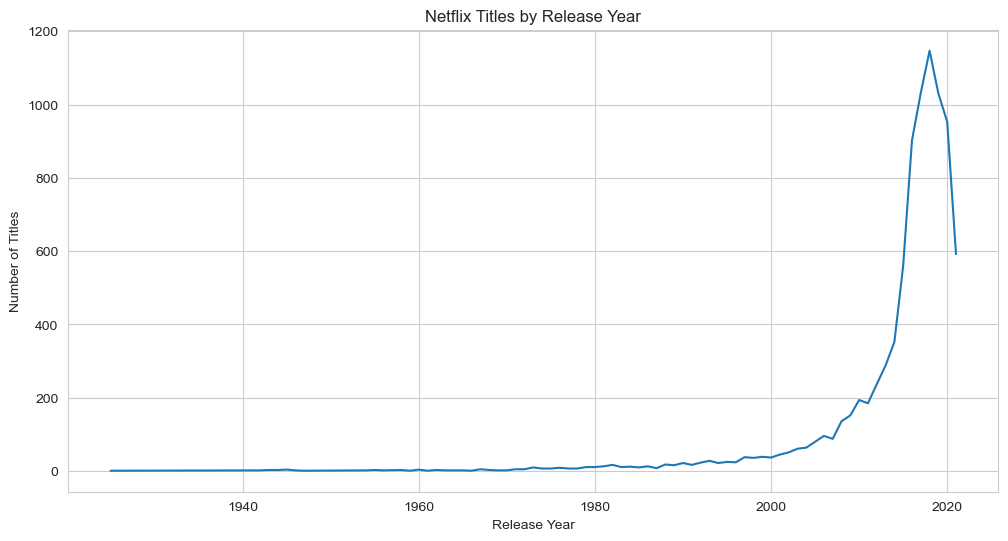


Titles Added by Year:
2008.0       2
2009.0       2
2010.0       1
2011.0      13
2012.0       3
2013.0      11
2014.0      24
2015.0      82
2016.0     429
2017.0    1188
2018.0    1649
2019.0    2016
2020.0    1879
2021.0    1498
Name: added_year, dtype: int64


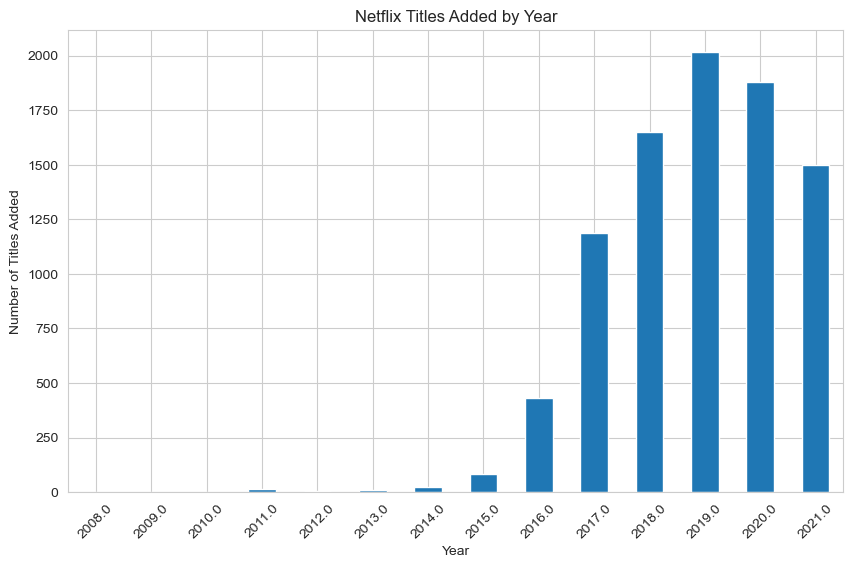


Netflix Content Growth:
added_year
2008.0       2
2009.0       2
2010.0       1
2011.0      13
2012.0       3
2013.0      11
2014.0      24
2015.0      82
2016.0     429
2017.0    1188
2018.0    1649
2019.0    2016
2020.0    1879
2021.0    1498
dtype: int64


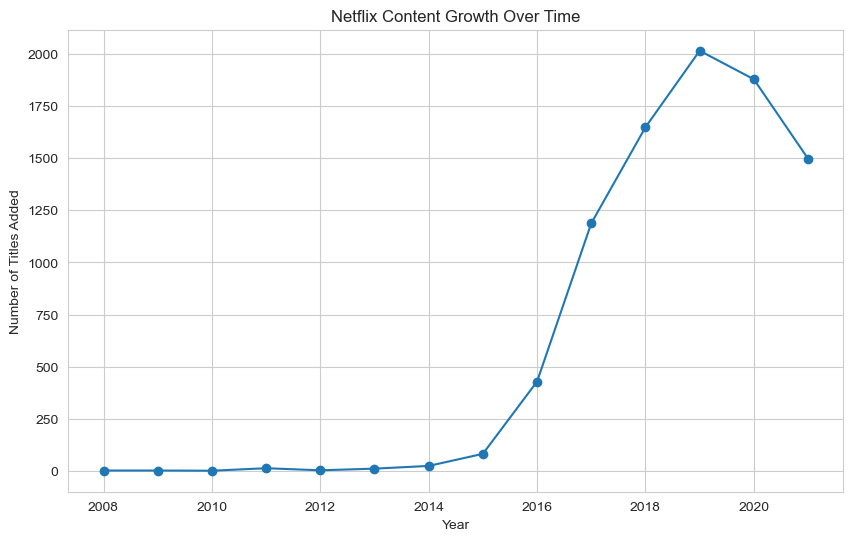


Movie Duration Statistics:
count    6128.000000
mean       99.577187
std        28.290593
min         3.000000
25%        87.000000
50%        98.000000
75%       114.000000
max       312.000000
Name: duration_minutes, dtype: float64


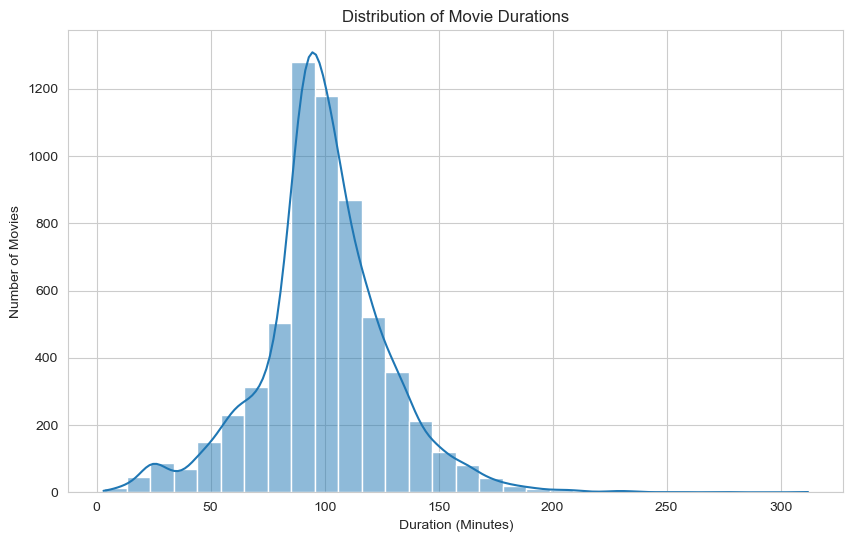


TV Shows by Number of Seasons:
1.0     1793
2.0      425
3.0      199
4.0       95
5.0       65
6.0       33
7.0       23
8.0       17
9.0        9
10.0       7
11.0       2
12.0       2
13.0       3
15.0       2
17.0       1
Name: seasons, dtype: int64


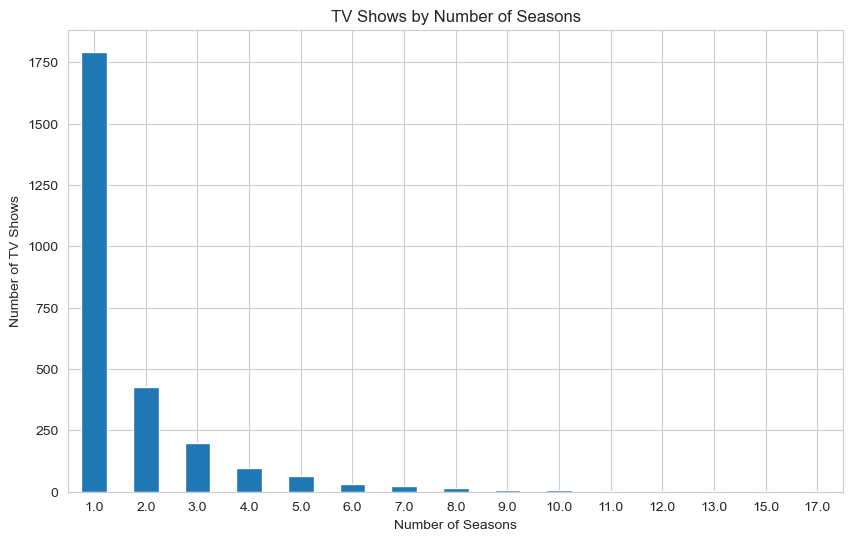


Top 10 Genres:
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1351
Documentaries                869
Action & Adventure           859
TV Dramas                    763
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: listed_in, dtype: int64


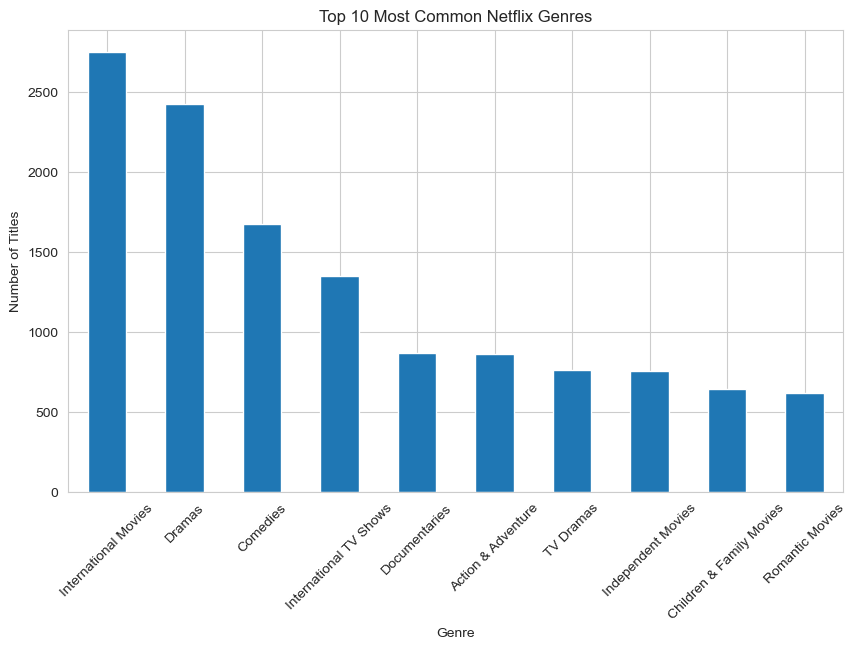


Top 10 Directors:
Rajiv Chilaka          22
Jan Suter              21
Raúl Campos            19
Suhas Kadav            16
Marcus Raboy           16
Jay Karas              15
Cathy Garcia-Molina    13
Jay Chapman            12
Youssef Chahine        12
Martin Scorsese        12
Name: director, dtype: int64


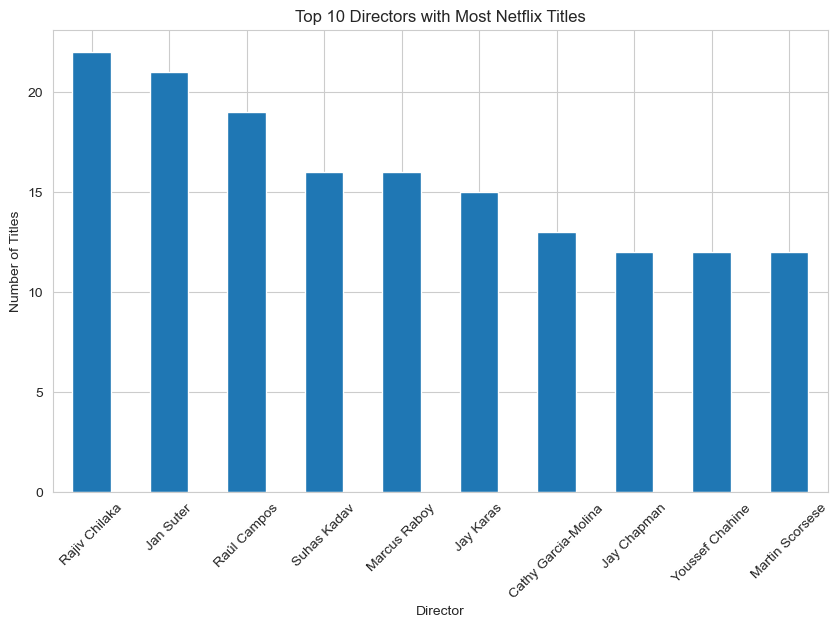


Top 10 Actors:
Anupam Kher         43
Shah Rukh Khan      35
Julie Tejwani       33
Naseeruddin Shah    32
Takahiro Sakurai    32
Rupa Bhimani        31
Akshay Kumar        30
Om Puri             30
Yuki Kaji           29
Paresh Rawal        28
Name: cast, dtype: int64


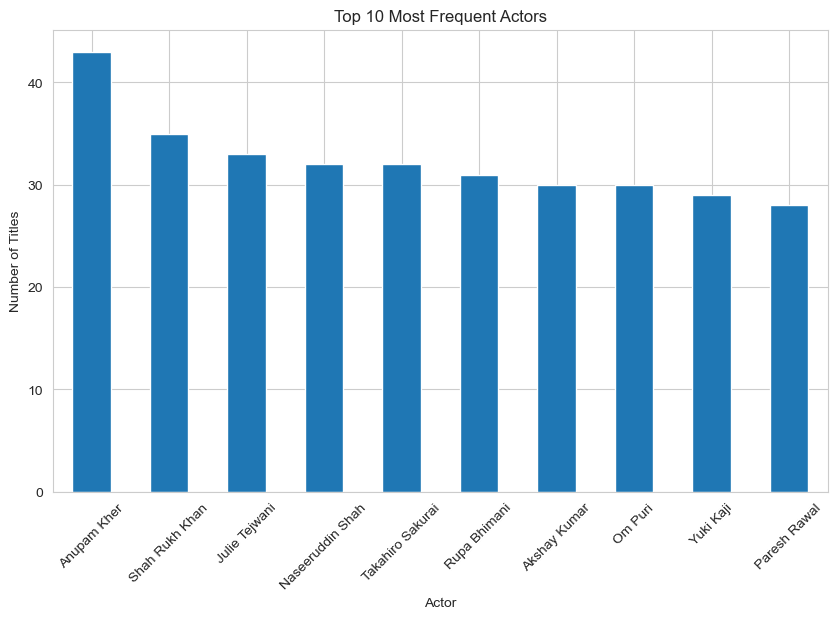


Most Common Words:
[('a', 11612), ('the', 8146), ('to', 6443), ('and', 6340), ('of', 5278), ('in', 4353), ('his', 3355), ('with', 2268), ('her', 2167), ('an', 1994), ('for', 1791), ('on', 1778), ('their', 1669), ('when', 1517), ('this', 1396), ('from', 1291), ('as', 1224), ('is', 1119), ('by', 1005), ('after', 993)]


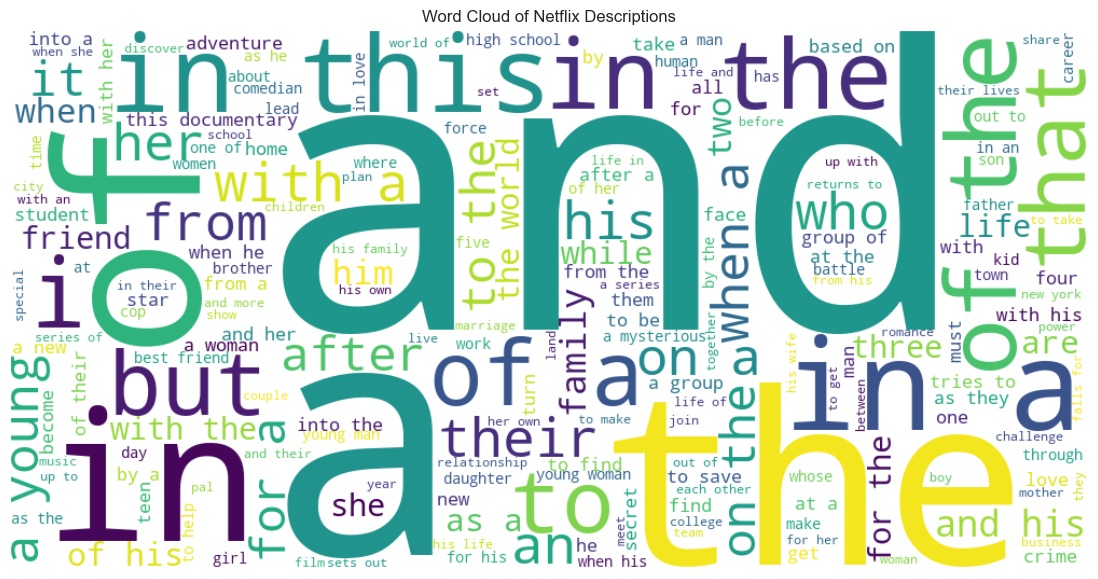

TypeError: list indices must be integers or slices, not float

In [1]:
# ============================================================
# AD23532 – PRINCIPLES OF DATA SCIENCE
# EX6a – EXPLORATORY DATA ANALYSIS ON NETFLIX TITLES
# ============================================================

# -----------------------------
# 1. IMPORT LIBRARIES
# -----------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from collections import Counter
from wordcloud import WordCloud

# Display settings
pd.set_option('display.max_columns', None)

# Plot style
sns.set_style("whitegrid")


# -----------------------------
# 2. LOAD DATASET
# -----------------------------

df = pd.read_csv(r"C:\Users\HDCO422184\Downloads\archive (7)\netflix_titles.csv")

print("Dataset loaded successfully!")
print("\nFirst 5 rows:")
print(df.head())


# -----------------------------
# 3. EXPLORE THE DATASET
# -----------------------------

print("\nShape of dataset:")
print(df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nDataset information:")
print(df.info())

print("\nMissing values:")
print(df.isnull().sum())

print("\nStatistical summary:")
print(df.describe(include="all"))


# -----------------------------
# 4. DATA PREPROCESSING
# -----------------------------

# Convert date_added into datetime
df["date_added"] = pd.to_datetime(df["date_added"], errors="coerce")

# Fill missing values
df["country"] = df["country"].fillna("Unknown")
df["director"] = df["director"].fillna("Unknown")
df["cast"] = df["cast"].fillna("Unknown")
df["rating"] = df["rating"].fillna("Unknown")
df["duration"] = df["duration"].fillna("Unknown")
df["listed_in"] = df["listed_in"].fillna("Unknown")
df["description"] = df["description"].fillna("")

print("\nMissing values after preprocessing:")
print(df.isnull().sum())


# ============================================================
# 5. CONTENT DISTRIBUTION ANALYSIS
# ============================================================

# 5a. Movies vs TV Shows

content_count = df["type"].value_counts()

print("\nMovies vs TV Shows:")
print(content_count)

plt.figure(figsize=(7,5))
sns.countplot(data=df, x="type")
plt.title("Movies vs TV Shows")
plt.xlabel("Content Type")
plt.ylabel("Number of Titles")
plt.show()


# 5b. Distribution of ratings

rating_count = df["rating"].value_counts()

print("\nRating Distribution:")
print(rating_count)

plt.figure(figsize=(10,6))
sns.countplot(
    data=df,
    y="rating",
    order=df["rating"].value_counts().index
)
plt.title("Distribution of Netflix Ratings")
plt.xlabel("Number of Titles")
plt.ylabel("Rating")
plt.show()


# 5c. Countries with most Netflix content

# Some rows contain multiple countries
countries = (
    df["country"]
    .str.split(", ")
    .explode()
)

country_count = countries.value_counts()

print("\nTop 10 Countries:")
print(country_count.head(10))

plt.figure(figsize=(10,6))
country_count.head(10).plot(kind="bar")
plt.title("Top 10 Countries by Netflix Content")
plt.xlabel("Country")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)
plt.show()


# ============================================================
# 6. TIME-BASED TREND ANALYSIS
# ============================================================

# 6a. Years in which most titles were released

release_year_count = df["release_year"].value_counts().sort_index()

print("\nTop 10 Release Years:")
print(df["release_year"].value_counts().head(10))

plt.figure(figsize=(12,6))
release_year_count.plot()
plt.title("Netflix Titles by Release Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
plt.show()


# 6b. Years in which titles were added to Netflix

df["added_year"] = df["date_added"].dt.year

added_year_count = df["added_year"].value_counts().sort_index()

print("\nTitles Added by Year:")
print(added_year_count)

plt.figure(figsize=(10,6))
added_year_count.plot(kind="bar")
plt.title("Netflix Titles Added by Year")
plt.xlabel("Year")
plt.ylabel("Number of Titles Added")
plt.xticks(rotation=45)
plt.show()


# 6c. Netflix content growth trend

growth = df.groupby("added_year").size()

print("\nNetflix Content Growth:")
print(growth)

plt.figure(figsize=(10,6))
growth.plot(marker="o")
plt.title("Netflix Content Growth Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Titles Added")
plt.grid(True)
plt.show()


# ============================================================
# 7. DURATION & CONTENT TYPE ANALYSIS
# ============================================================

# 7a. Movie duration distribution

movies = df[df["type"] == "Movie"].copy()

movies["duration_minutes"] = (
    movies["duration"]
    .str.extract(r"(\d+)")
    .astype(float)
)

print("\nMovie Duration Statistics:")
print(movies["duration_minutes"].describe())

plt.figure(figsize=(10,6))
sns.histplot(
    movies["duration_minutes"].dropna(),
    bins=30,
    kde=True
)
plt.title("Distribution of Movie Durations")
plt.xlabel("Duration (Minutes)")
plt.ylabel("Number of Movies")
plt.show()


# 7b. TV shows by number of seasons

tv_shows = df[df["type"] == "TV Show"].copy()

tv_shows["seasons"] = (
    tv_shows["duration"]
    .str.extract(r"(\d+)")
    .astype(float)
)

season_count = tv_shows["seasons"].value_counts().sort_index()

print("\nTV Shows by Number of Seasons:")
print(season_count)

plt.figure(figsize=(10,6))
season_count.plot(kind="bar")
plt.title("TV Shows by Number of Seasons")
plt.xlabel("Number of Seasons")
plt.ylabel("Number of TV Shows")
plt.xticks(rotation=0)
plt.show()


# ============================================================
# 8. GENRE & CATEGORY ANALYSIS
# ============================================================

# 8a. Top 10 most common genres

genres = (
    df["listed_in"]
    .str.split(", ")
    .explode()
)

genre_count = genres.value_counts()

print("\nTop 10 Genres:")
print(genre_count.head(10))

plt.figure(figsize=(10,6))
genre_count.head(10).plot(kind="bar")
plt.title("Top 10 Most Common Netflix Genres")
plt.xlabel("Genre")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)
plt.show()


# 8b. Directors with most titles

directors = (
    df[df["director"] != "Unknown"]["director"]
    .str.split(", ")
    .explode()
)

director_count = directors.value_counts()

print("\nTop 10 Directors:")
print(director_count.head(10))

plt.figure(figsize=(10,6))
director_count.head(10).plot(kind="bar")
plt.title("Top 10 Directors with Most Netflix Titles")
plt.xlabel("Director")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)
plt.show()


# 8c. Actors appearing most frequently

actors = (
    df[df["cast"] != "Unknown"]["cast"]
    .str.split(", ")
    .explode()
)

actor_count = actors.value_counts()

print("\nTop 10 Actors:")
print(actor_count.head(10))

plt.figure(figsize=(10,6))
actor_count.head(10).plot(kind="bar")
plt.title("Top 10 Most Frequent Actors")
plt.xlabel("Actor")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)
plt.show()


# ============================================================
# 9. TEXT & DESCRIPTION ANALYSIS
# ============================================================

# Combine all descriptions

text = " ".join(df["description"].astype(str))

# Convert to lowercase
text = text.lower()

# Remove punctuation and numbers
text = re.sub(r"[^a-zA-Z\s]", "", text)

# Split into words
words = text.split()

# Count words
word_count = Counter(words)

# Display most common words
print("\nMost Common Words:")
print(word_count.most_common(20))


# Word cloud

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white",
    stopwords=set()
).generate(text)

plt.figure(figsize=(15,7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of Netflix Descriptions")
plt.show()


# ============================================================
# 10. MONTHS WHEN NETFLIX ADDS MOST CONTENT
# ============================================================

df["added_month"] = df["date_added"].dt.month

month_count = df["added_month"].value_counts().sort_index()

month_names = [
    "January", "February", "March", "April",
    "May", "June", "July", "August",
    "September", "October", "November", "December"
]

month_count.index = [
    month_names[i-1] for i in month_count.index
]

print("\nContent Added by Month:")
print(month_count)

plt.figure(figsize=(12,6))
month_count.plot(kind="bar")
plt.title("Netflix Content Added by Month")
plt.xlabel("Month")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)
plt.show()


# ============================================================
# 11. COUNTRIES PRODUCING MOVIES VS TV SHOWS
# ============================================================

# Movies by country

movie_country = (
    df[df["type"] == "Movie"]["country"]
    .str.split(", ")
    .explode()
)

movie_country_count = movie_country.value_counts()

print("\nTop Countries Producing Movies:")
print(movie_country_count.head(10))


# TV Shows by country

tv_country = (
    df[df["type"] == "TV Show"]["country"]
    .str.split(", ")
    .explode()
)

tv_country_count = tv_country.value_counts()

print("\nTop Countries Producing TV Shows:")
print(tv_country_count.head(10))


# Plot comparison

fig, axes = plt.subplots(1, 2, figsize=(16,6))

movie_country_count.head(10).plot(
    kind="bar",
    ax=axes[0]
)

axes[0].set_title("Top Countries Producing Movies")
axes[0].set_xlabel("Country")
axes[0].set_ylabel("Number of Movies")
axes[0].tick_params(axis="x", rotation=45)


tv_country_count.head(10).plot(
    kind="bar",
    ax=axes[1]
)

axes[1].set_title("Top Countries Producing TV Shows")
axes[1].set_xlabel("Country")
axes[1].set_ylabel("Number of TV Shows")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


# ============================================================
# 12. MOST COMMON RATINGS FOR MOVIES VS TV SHOWS
# ============================================================

movie_ratings = (
    df[df["type"] == "Movie"]["rating"]
    .value_counts()
)

tv_ratings = (
    df[df["type"] == "TV Show"]["rating"]
    .value_counts()
)

print("\nMost Common Movie Ratings:")
print(movie_ratings)

print("\nMost Common TV Show Ratings:")
print(tv_ratings)


fig, axes = plt.subplots(1, 2, figsize=(16,6))

movie_ratings.head(10).plot(
    kind="bar",
    ax=axes[0]
)

axes[0].set_title("Movie Ratings")
axes[0].set_xlabel("Rating")
axes[0].set_ylabel("Number of Movies")
axes[0].tick_params(axis="x", rotation=45)


tv_ratings.head(10).plot(
    kind="bar",
    ax=axes[1]
)

axes[1].set_title("TV Show Ratings")
axes[1].set_xlabel("Rating")
axes[1].set_ylabel("Number of TV Shows")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


# ============================================================
# 13. OLDEST AND NEWEST TITLES
# ============================================================

oldest_year = df["release_year"].min()
newest_year = df["release_year"].max()

print("\nOldest Release Year:", oldest_year)
print("Newest Release Year:", newest_year)

print("\nOldest Titles:")
print(
    df[df["release_year"] == oldest_year]
    [["title", "type", "release_year", "country"]]
)

print("\nNewest Titles:")
print(
    df[df["release_year"] == newest_year]
    [["title", "type", "release_year", "country"]]
)


# ============================================================
# 14. GENRE CO-OCCURRENCE CORRELATION HEATMAP
# ============================================================

# Select top genres
top_genres = genre_count.head(10).index.tolist()

# Create binary columns for each genre
for genre in top_genres:
    df[genre] = df["listed_in"].apply(
        lambda x: 1 if genre in x else 0
    )

# Calculate correlation
genre_corr = df[top_genres].corr()

print("\nGenre Correlation Matrix:")
print(genre_corr)


# Heatmap

plt.figure(figsize=(12,10))

sns.heatmap(
    genre_corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Genre Correlation Heatmap")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()


# ============================================================
# 15. FINAL SUMMARY
# ============================================================

print("\n" + "="*60)
print("FINAL EDA SUMMARY")
print("="*60)

print("\nTotal number of titles:", len(df))

print("\nContent distribution:")
print(content_count)

print("\nTop 5 countries:")
print(country_count.head(5))

print("\nTop 5 genres:")
print(genre_count.head(5))

print("\nTop 5 directors:")
print(director_count.head(5))

print("\nTop 5 actors:")
print(actor_count.head(5))

print("\nMost common movie ratings:")
print(movie_ratings.head(5))

print("\nMost common TV show ratings:")
print(tv_ratings.head(5))

print("\nOldest release year:", oldest_year)
print("Newest release year:", newest_year)

print("\nEDA COMPLETED SUCCESSFULLY!")